In [2]:
import polars as pl
from plotnine import *
import re

theme_set(theme_bw())

In [3]:
# command for generating the s3_status.json file (it isn't actually JSON though, don't know why)
# aws s3 ls --output json s3://sandpiper-woodcrob/test/ >s3_status.json
# aws s3 ls --output json s3://woodcrob-sandpiper-us-east-1/unannotated/ >s3_status.json


# Preprocess the file
with open('s3_status.json', 'r') as file:
    content = file.read()

# Replace multiple delimiters with a single delimiter (e.g., ',')
content = re.sub(r' +', ' ', content)

# Write the preprocessed content to a temporary file
with open('/tmp/temp.csv', 'w') as temp_file:
    temp_file.write(content)

# Read the preprocessed file into Polars
df = pl.read_csv('/tmp/temp.csv')

s3 = pl.read_csv('/tmp/temp.csv', has_header=False, separator=' ')
s3[:3], s3[-3:]

(shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪══════════╪═════════════════════════════════╡
 │ 2025-02-28 ┆ 14:07:08 ┆ 167496   ┆ DRR003618.unannotated.singlem.… │
 │ 2025-02-27 ┆ 21:13:31 ┆ 306707   ┆ DRR003623.unannotated.singlem.… │
 │ 2025-02-27 ┆ 18:58:02 ┆ 395471   ┆ DRR003635.unannotated.singlem.… │
 └────────────┴──────────┴──────────┴─────────────────────────────────┘,
 shape: (3, 4)
 ┌────────────┬──────────┬──────────┬─────────────────────────────────┐
 │ column_1   ┆ column_2 ┆ column_3 ┆ column_4                        │
 │ ---        ┆ ---      ┆ ---      ┆ ---                             │
 │ str        ┆ str      ┆ i64      ┆ str                             │
 ╞════════════╪══════════╪═══════

In [4]:
s3.columns = ['date', 'time', 'size','file']
s3[:3]

date,time,size,file
str,str,i64,str
"""2025-02-28""","""14:07:08""",167496,"""DRR003618.unannotated.singlem.…"
"""2025-02-27""","""21:13:31""",306707,"""DRR003623.unannotated.singlem.…"
"""2025-02-27""","""18:58:02""",395471,"""DRR003635.unannotated.singlem.…"


In [5]:
s3 = s3.with_columns(pl.col('file').str.split('.').list.get(0).alias('acc'))
# date and time are in separate columns, so we need to combine them into a single column datetime
s3 = s3.with_columns((pl.col('date') + ' ' + pl.col('time')).str.to_datetime("%Y-%m-%d %H:%M:%S").alias('datetime'))
s3[:3]

date,time,size,file,acc,datetime
str,str,i64,str,str,datetime[μs]
"""2025-02-28""","""14:07:08""",167496,"""DRR003618.unannotated.singlem.…","""DRR003618""",2025-02-28 14:07:08
"""2025-02-27""","""21:13:31""",306707,"""DRR003623.unannotated.singlem.…","""DRR003623""",2025-02-27 21:13:31
"""2025-02-27""","""18:58:02""",395471,"""DRR003635.unannotated.singlem.…","""DRR003635""",2025-02-27 18:58:02


In [6]:
# Original data
acc20k = pl.read_csv('runlists/acc_less_than_20k_mbytes.csv', has_header=False)
acc20k.columns = ['acc']
acc20k[:3]

df = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns.csv.gz', has_header=False)
df.columns = ['acc','releasedate','mbases','mbytes']
df[:4]

merged20k = acc20k.join(df, on='acc', how='inner')
merged20k[:3], merged20k.shape

(shape: (3, 4)
 ┌─────────────┬───────────────────────────┬────────┬────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    │
 │ str         ┆ str                       ┆ i64    ┆ i64    │
 ╞═════════════╪═══════════════════════════╪════════╪════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    │
 └─────────────┴───────────────────────────┴────────┴────────┘,
 (710928, 4))

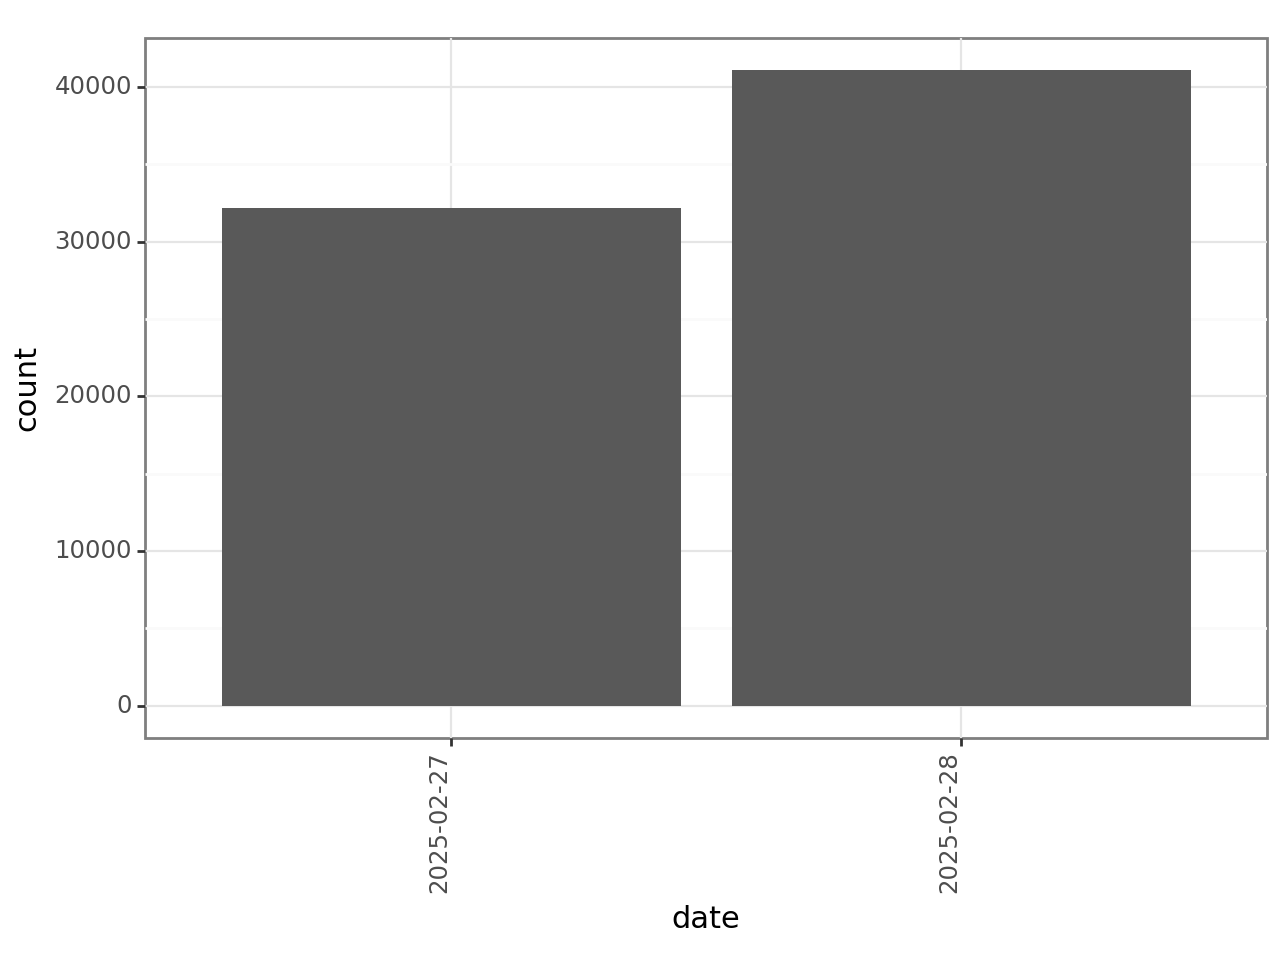

<Figure Size: (640 x 480)>

In [7]:
# plot number of acc finished per day
ggplot(data=s3)+geom_bar(aes(x='date'))+theme(axis_text_x=element_text(rotation=90, hjust=1))

In [8]:
# Are larger files being processed? Plot the number of files processed per day, colored by size
joined = merged20k.join(s3, on='acc', how='left')
joined.filter(pl.col('size')>0)[:3]

acc,releasedate,mbases,mbytes,date,time,size,file,datetime
str,str,i64,i64,str,str,i64,str,datetime[μs]
"""SRR15442735""","""2021-08-13T00:00:00+00:00""",6638,2614,"""2025-02-27""","""16:36:49""",10170,"""SRR15442735.unannotated.single…",2025-02-27 16:36:49
"""ERR1959224""","""2017-07-08T00:00:00+00:00""",8555,3195,"""2025-02-27""","""17:30:39""",1138850,"""ERR1959224.unannotated.singlem…",2025-02-27 17:30:39
"""ERR5003368""","""2020-12-23T00:00:00+00:00""",1013,344,"""2025-02-27""","""16:17:28""",433726,"""ERR5003368.unannotated.singlem…",2025-02-27 16:17:28


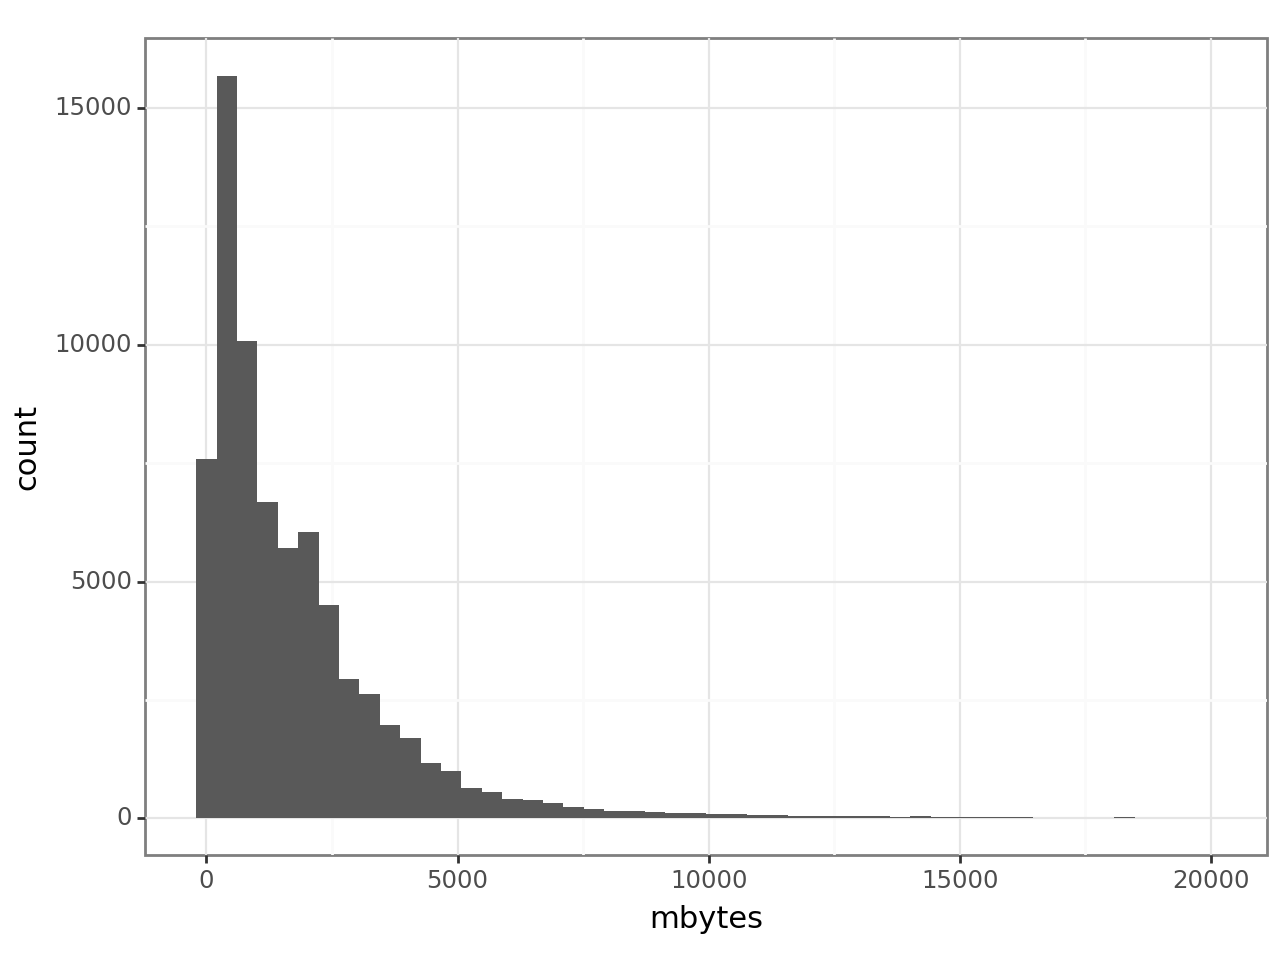

<Figure Size: (640 x 480)>

In [9]:
ggplot(joined.filter(pl.col('size')>0))+geom_histogram(aes(x='mbytes'), bins=50)

shape: (2, 2)
┌───────┬────────┐
│ done  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ false ┆ 637658 │
│ true  ┆ 73270  │
└───────┴────────┘


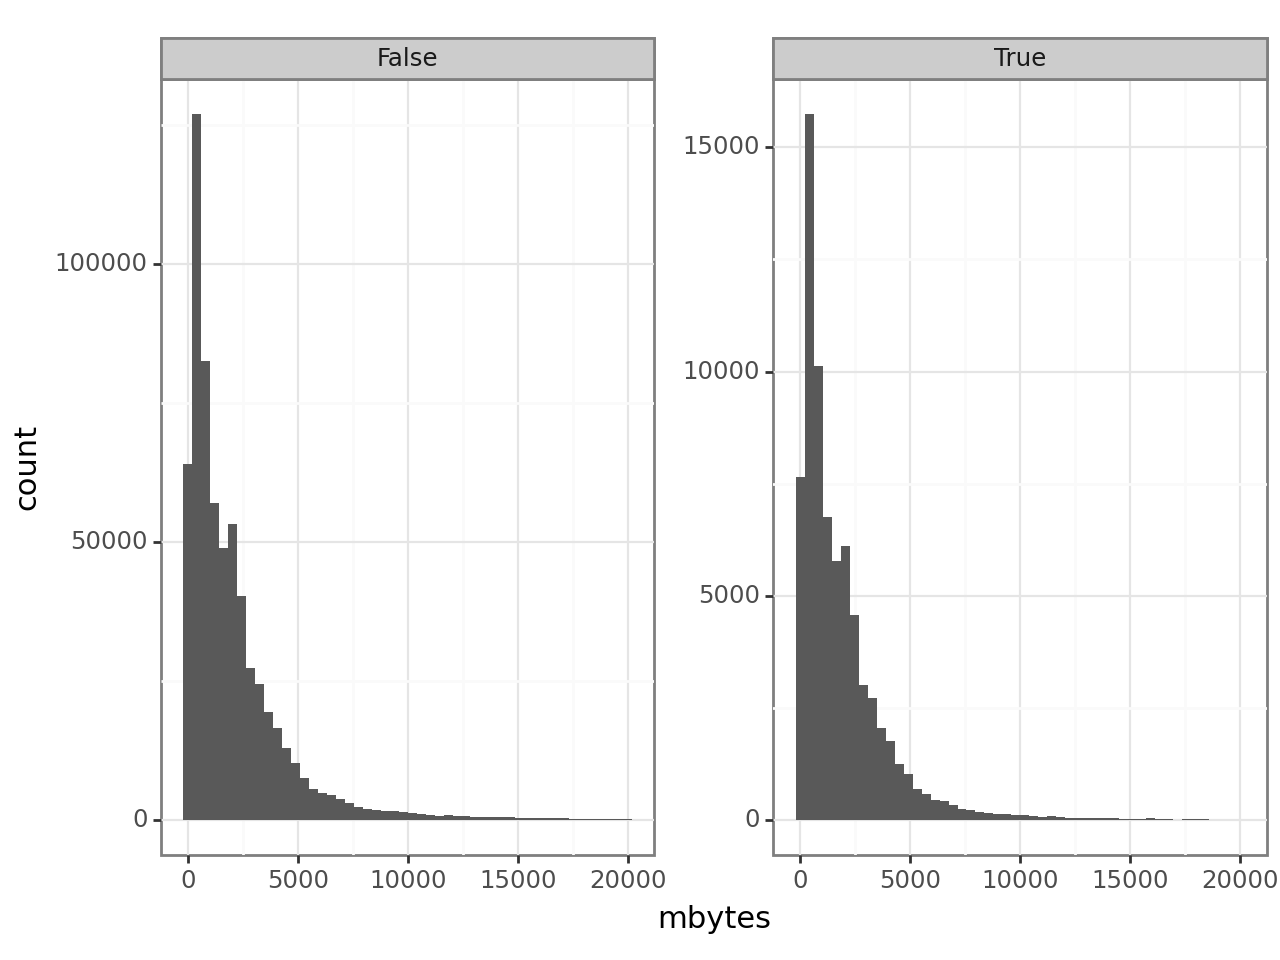

<Figure Size: (640 x 480)>

In [10]:
joined = joined.with_columns(~pl.col('size').is_null().alias('done'))
print(joined.group_by('done').len())
# ggplot(joined)+geom_density(aes(x='mbases'))#, colour='done')
# ggplot(joined.filter(pl.col('done')))+geom_histogram(aes(x='mbytes'), bins=50)
ggplot(joined)+geom_histogram(aes(x='mbytes'), bins=50)+ facet_wrap('done', scales='free_y')

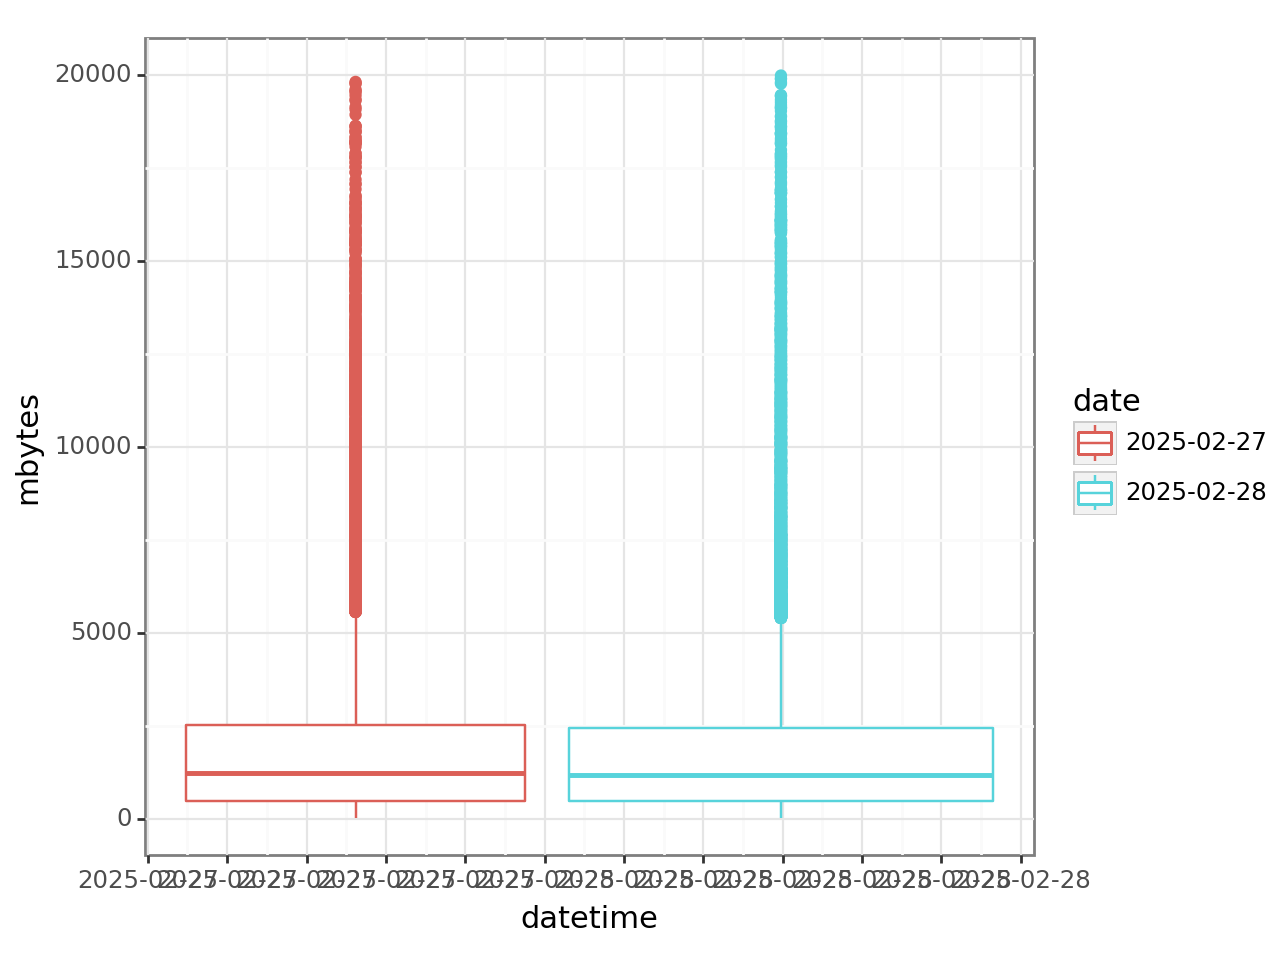

<Figure Size: (640 x 480)>

In [11]:
# Plot size vs date
ggplot(joined.filter(pl.col('done')))+geom_boxplot(aes(x='datetime', y='mbytes', colour='date'))

In [12]:
joined.filter(pl.col('done')).select('date','mbytes').group_by('date').median(), joined.select(pl.col('mbytes')).median()

(shape: (2, 2)
 ┌────────────┬────────┐
 │ date       ┆ mbytes │
 │ ---        ┆ ---    │
 │ str        ┆ f64    │
 ╞════════════╪════════╡
 │ 2025-02-28 ┆ 1175.0 │
 │ 2025-02-27 ┆ 1225.5 │
 └────────────┴────────┘,
 shape: (1, 1)
 ┌────────┐
 │ mbytes │
 │ ---    │
 │ f64    │
 ╞════════╡
 │ 1319.0 │
 └────────┘)

In [13]:
# DONT DO THIS - RAM ISSUES
# # ggplot(joined)+geom_density(aes(x='mbytes', colour='done'))

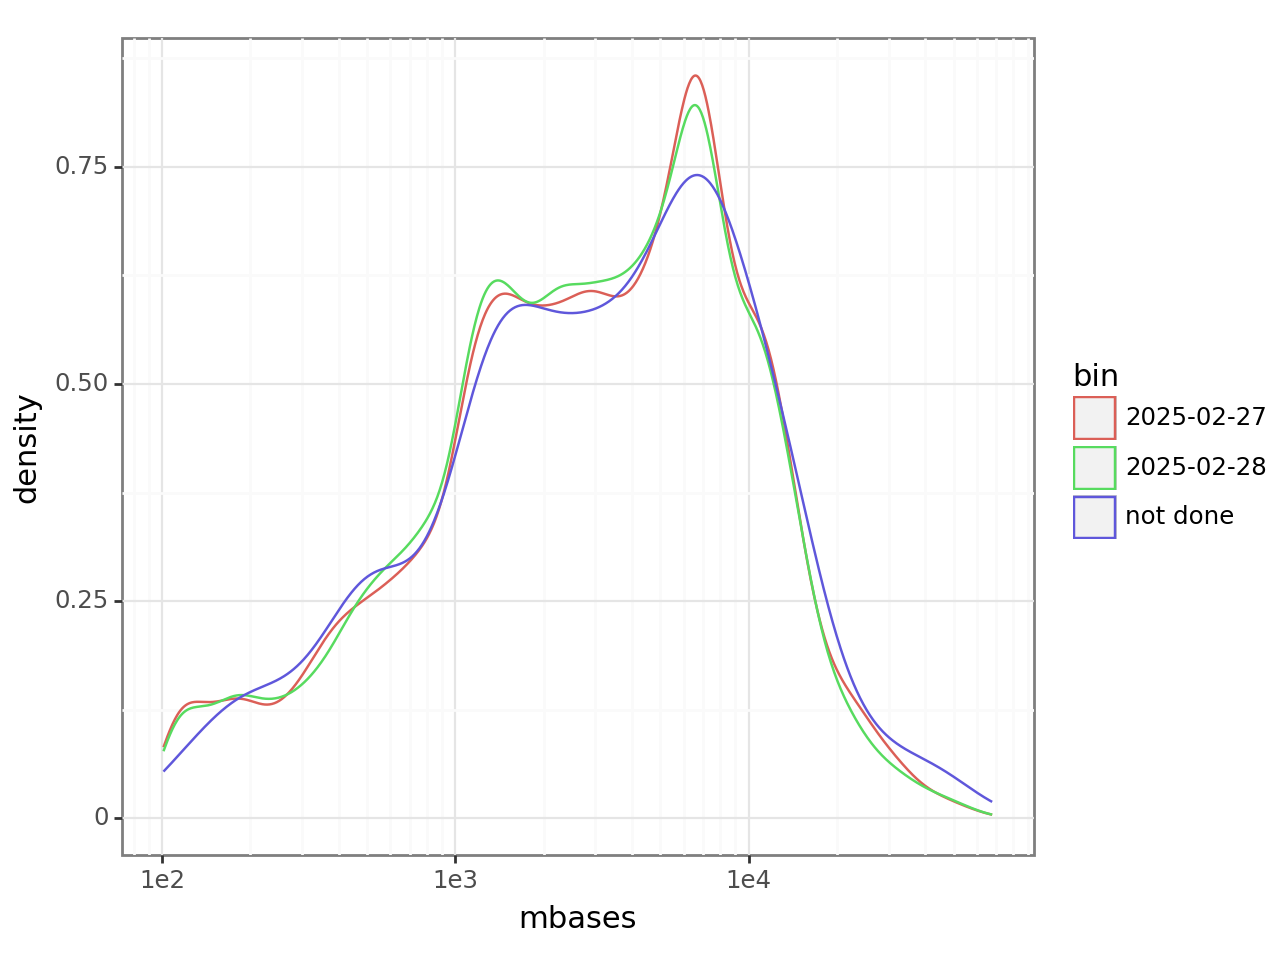

<Figure Size: (640 x 480)>

In [14]:
overall_sample = joined.filter(pl.col('done')==False).sample(1000)

to_plot = pl.concat([overall_sample, joined.filter(pl.col('done'))]).with_columns(pl.when(pl.col('done')==True).then(pl.col('date')).otherwise(pl.lit('not done')).alias('bin'))

to_plot.sample(50)
ggplot(to_plot)+geom_density(aes(x='mbases', colour='bin'))+scale_x_log10()

In [15]:
# estimate total time required to process all files. Time taken is the time since the first file appeared in the S3 bucket
start_time = joined.filter(pl.col('done')).with_columns(pl.col('datetime').min().alias('start'))['start'][0]
# joined.filter(pl.col('datetime')==start_time)
print(start_time)
import datetime
time_since_start = datetime.datetime.now() - start_time
print(time_since_start)
num_to_do = joined.shape[0] - 18831 # minus us-east-2
num_to_do / joined.filter(pl.col('done')).shape[0] * time_since_start, joined.group_by('done').len(), joined.filter(pl.col('done')).shape[0] / num_to_do * 100, joined.filter(pl.col('done')).select('mbases').sum()[0,0] / joined.select('mbases').sum()[0,0] * 100

# but that's an underestimate because smaller files are processed faster, so more likely to be already done.

2025-02-27 09:43:03
10 days, 8:24:46.848857


(datetime.timedelta(days=97, seconds=66494, microseconds=189073),
 shape: (2, 2)
 ┌───────┬────────┐
 │ done  ┆ len    │
 │ ---   ┆ ---    │
 │ bool  ┆ u32    │
 ╞═══════╪════════╡
 │ false ┆ 637658 │
 │ true  ┆ 73270  │
 └───────┴────────┘,
 10.586666319894466,
 9.283281209222881)

In [16]:
(412005+119021+18831)/df.shape[0], (471178+119021+18831)/df.shape[0]

(0.702060124743841, 0.7776125024738095)

In [17]:
df.filter(pl.col('mbases') >= 8000).sample(5)

acc,releasedate,mbases,mbytes
str,str,i64,i64
"""SRR27258020""","""2023-12-18T00:00:00+00:00""",14331,6302
"""SRR13132391""","""2020-11-25T00:00:00+00:00""",13207,4356
"""ERR5621739""","""2021-05-19T00:00:00+00:00""",9556,3616
"""SRR15172852""","""2021-12-28T00:00:00+00:00""",21432,8286
"""SRR24234332""","""2023-04-20T00:00:00+00:00""",30365,11993


In [18]:
# How many GBytes of data >= 8000 ? A lot...
df.filter(pl.col('mbases') >= 8000).select('mbytes').sum()[0,0] / 1e6, df.filter(pl.col('mbases') < 8000).select('mbytes').sum()[0,0] / 1e6, df.filter(pl.col('mbases') > 50000).select('mbytes').sum()[0,0] / 1e6

(1099.691055, 663.890644, 145.034145)

In [19]:
# How many runs?
df.filter(pl.col('mbases') >= 8000).shape[0] / df.shape[0], df.filter(pl.col('mbases') >= 50000).shape[0] / df.shape[0]

(0.2386361169808671, 0.007150107570814793)

# Size of s3 so far

In [20]:
# Try those < 8gbases again where they failed - maybe the increased RAM of a this batch will get them through?
import extern
extern.run('cat s3_ls/* |grep RR |sed "s/  */\t/g" >/tmp/runs')

prev4 = pl.read_csv('/tmp/runs', has_header=False, separator='\t')
prev4.columns = ["acc", "time", "size", "path"]
print(prev4.group_by(pl.col('size') > 0).len())
prev5 = prev4.filter(pl.col('size') > 0).with_columns(pl.col("path").alias("acc").str.split('.').list.get(0))
prev5.shape, prev5.select(pl.col('size').sum())[0,0] / 1e9

shape: (2, 2)
┌───────┬────────┐
│ size  ┆ len    │
│ ---   ┆ ---    │
│ bool  ┆ u32    │
╞═══════╪════════╡
│ false ┆ 8769   │
│ true  ┆ 591446 │
└───────┴────────┘


((591446, 4), 330.521209244)

# How many human metagenomes? Seems a lot

In [21]:
with_human = pl.read_csv('~/git/sandpiper/sra_metadata/sra_metadata_20250220.some_columns2.csv.gz', has_header=False)
with_human.columns = ['acc','releasedate','mbases','mbytes','organism']
with_human.shape, with_human[:3]

((783205, 5),
 shape: (3, 5)
 ┌─────────────┬───────────────────────────┬────────┬────────┬──────────────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes ┆ organism         │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    ┆ ---              │
 │ str         ┆ str                       ┆ i64    ┆ i64    ┆ str              │
 ╞═════════════╪═══════════════════════════╪════════╪════════╪══════════════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   ┆ viral metagenome │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   ┆ feces metagenome │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    ┆ gut metagenome   │
 └─────────────┴───────────────────────────┴────────┴────────┴──────────────────┘)

In [22]:
with_human = with_human.with_columns((pl.col('organism').str.contains('gut') | pl.col('organism').str.contains('feces') | pl.col('organism').str.contains('human')).alias('is_human'))
humans = with_human.filter(pl.col('is_human'))
with_human.shape, with_human[:3], humans.shape[0], with_human.filter(~pl.col('is_human')).shape[0], humans.shape[0] / with_human.shape[0] * 100

((783205, 6),
 shape: (3, 6)
 ┌─────────────┬───────────────────────────┬────────┬────────┬──────────────────┬──────────┐
 │ acc         ┆ releasedate               ┆ mbases ┆ mbytes ┆ organism         ┆ is_human │
 │ ---         ┆ ---                       ┆ ---    ┆ ---    ┆ ---              ┆ ---      │
 │ str         ┆ str                       ┆ i64    ┆ i64    ┆ str              ┆ bool     │
 ╞═════════════╪═══════════════════════════╪════════╪════════╪══════════════════╪══════════╡
 │ SRR15442735 ┆ 2021-08-13T00:00:00+00:00 ┆ 6638   ┆ 2614   ┆ viral metagenome ┆ false    │
 │ ERR1959224  ┆ 2017-07-08T00:00:00+00:00 ┆ 8555   ┆ 3195   ┆ feces metagenome ┆ true     │
 │ ERR5003368  ┆ 2020-12-23T00:00:00+00:00 ┆ 1013   ┆ 344    ┆ gut metagenome   ┆ true     │
 └─────────────┴───────────────────────────┴────────┴────────┴──────────────────┴──────────┘,
 386772,
 395778,
 49.383239381771055)

In [23]:
with_human = with_human.with_columns(pl.col('releasedate').str.to_datetime("%Y-%m-%dT00:00:00+00:00").alias('year').dt.year())
by_year = with_human.group_by('is_human', 'year').len()
by_year[:4]

is_human,year,len
bool,i32,u32
true,2013,2670
true,2015,10854
false,2021,35259
false,2023,70701


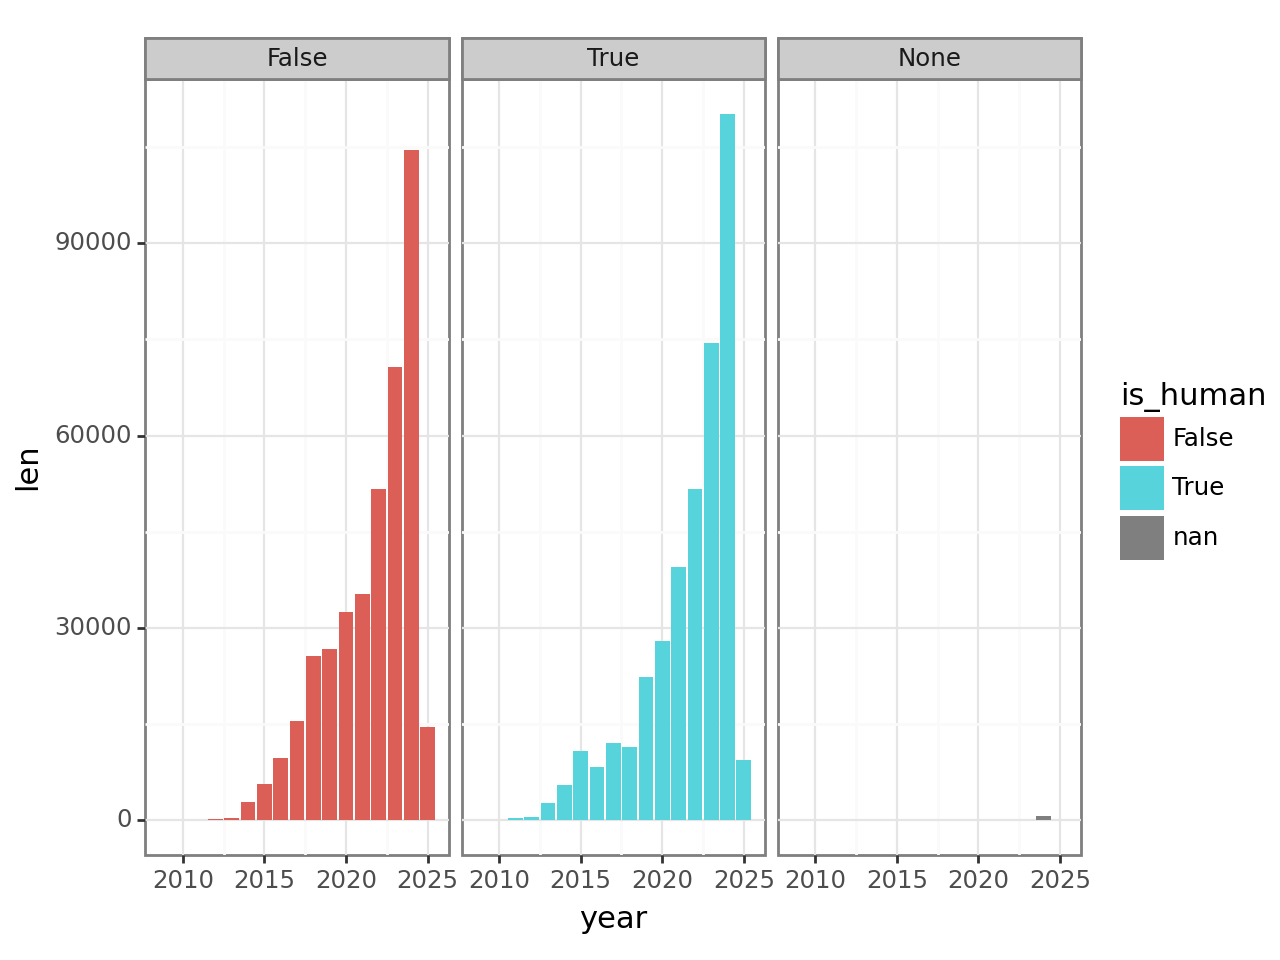

<Figure Size: (640 x 480)>

In [24]:
ggplot(by_year)+geom_bar(aes(x='year', y='len', fill='is_human'), stat='identity') + facet_wrap('is_human')

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


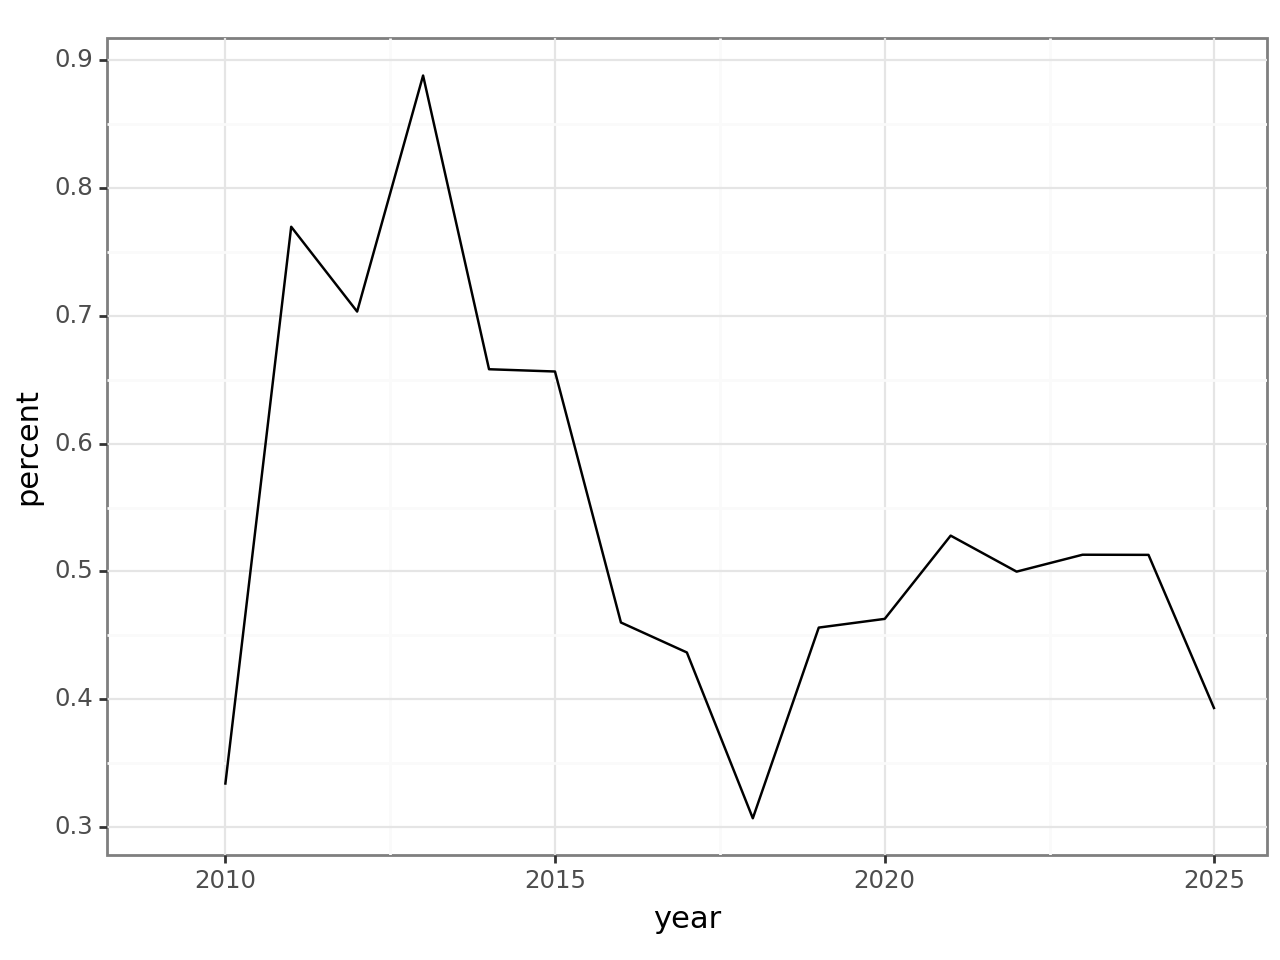

<Figure Size: (640 x 480)>

In [25]:
by_year2 = by_year.pivot('is_human', values='len')#, 'year', 'len')
by_year2 = by_year2.with_columns((pl.col('true') / (pl.col('true') + pl.col('false'))).alias('percent'))
ggplot(by_year2) + geom_line(aes(x='year', y='percent'))

In [26]:
with_human.sample(10)

acc,releasedate,mbases,mbytes,organism,is_human,year
str,str,i64,i64,str,bool,i32
"""ERR10157465""","""2022-09-27T00:00:00+00:00""",902,365,"""human metagenome""",true,2022
"""ERR10641095""","""2022-12-12T00:00:00+00:00""",12069,3495,"""Synchytrium endobioticum""",false,2022
"""ERR11646747""","""2023-09-21T00:00:00+00:00""",2129,510,"""unidentified""",false,2023
"""SRR13077925""","""2021-01-12T00:00:00+00:00""",2984,972,"""human gut metagenome""",true,2021
"""SRR28094969""","""2024-02-26T00:00:00+00:00""",5219,1640,"""freshwater sediment metagenome""",false,2024
"""SRR29093029""","""2024-05-21T00:00:00+00:00""",11340,3526,"""soil metagenome""",false,2024
"""ERR11768902""","""2023-09-01T00:00:00+00:00""",1050,266,"""poultry litter metagenome""",false,2023
"""SRR11814490""","""2020-05-19T00:00:00+00:00""",6800,2738,"""aquatic metagenome""",false,2020
"""SRR7464449""","""2019-07-28T00:00:00+00:00""",742,269,"""parchment metagenome""",false,2019


/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


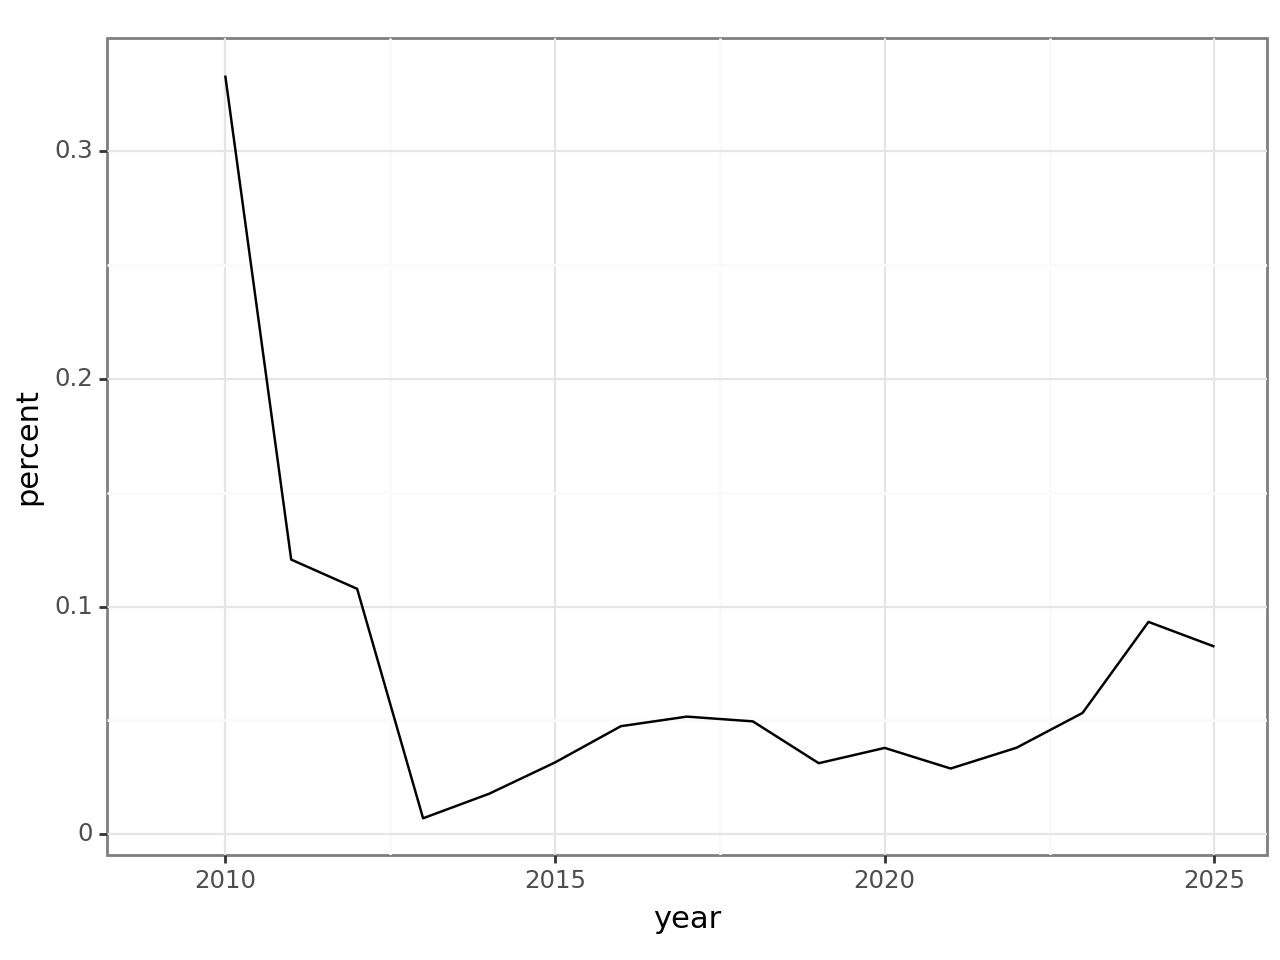

<Figure Size: (640 x 480)>

In [27]:
# soil metagenomes over time
soil_by_year = with_human.group_by(('year', pl.col('organism').str.contains('soil').alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 2 rows containing missing values.


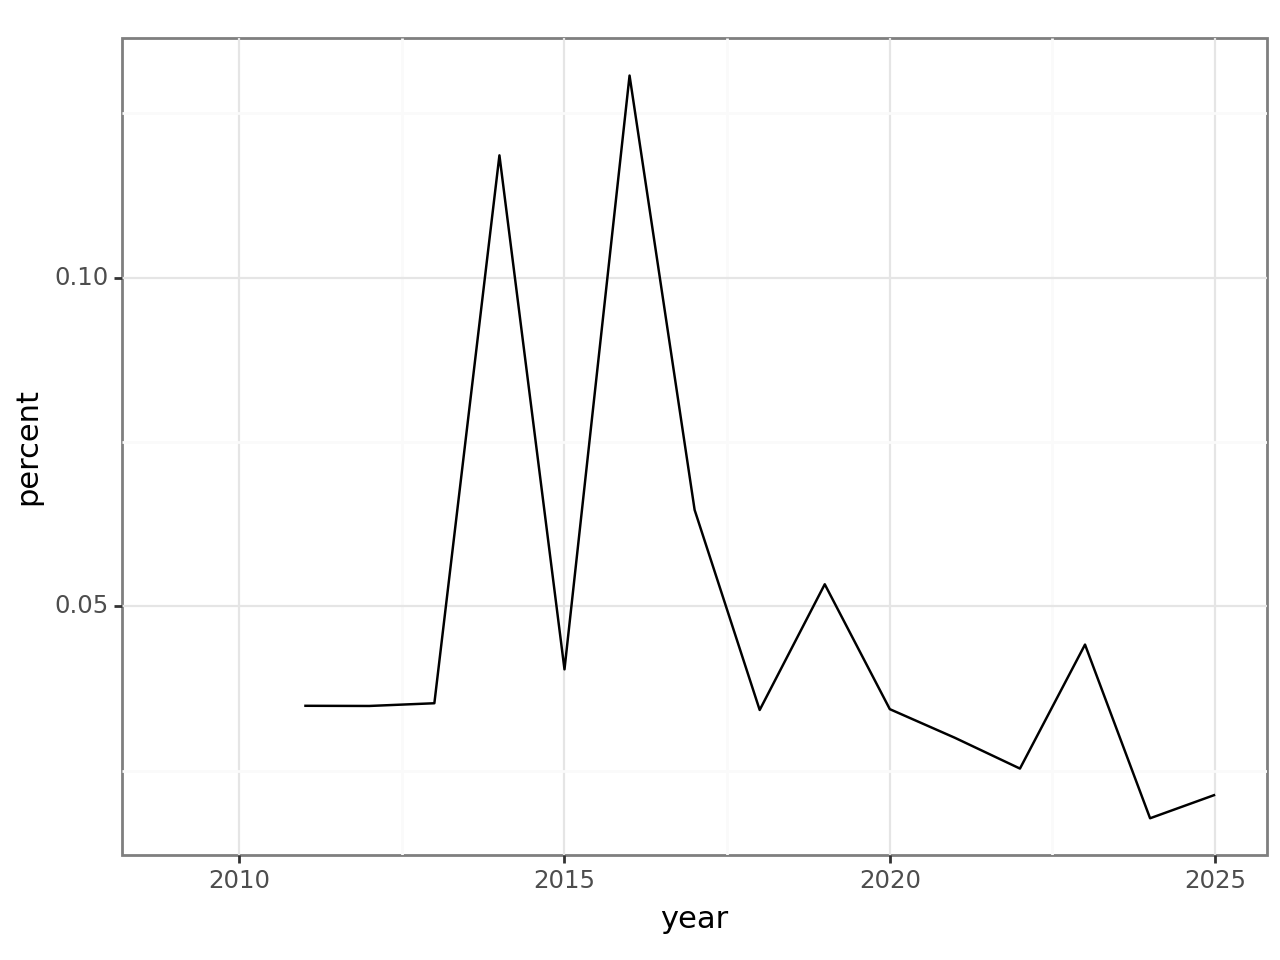

<Figure Size: (640 x 480)>

In [28]:
# marine
soil_by_year = with_human.group_by(('year', pl.col('organism').str.contains('marine').alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

/home/ben/e/mybase/lib/python3.11/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 1 rows containing missing values.


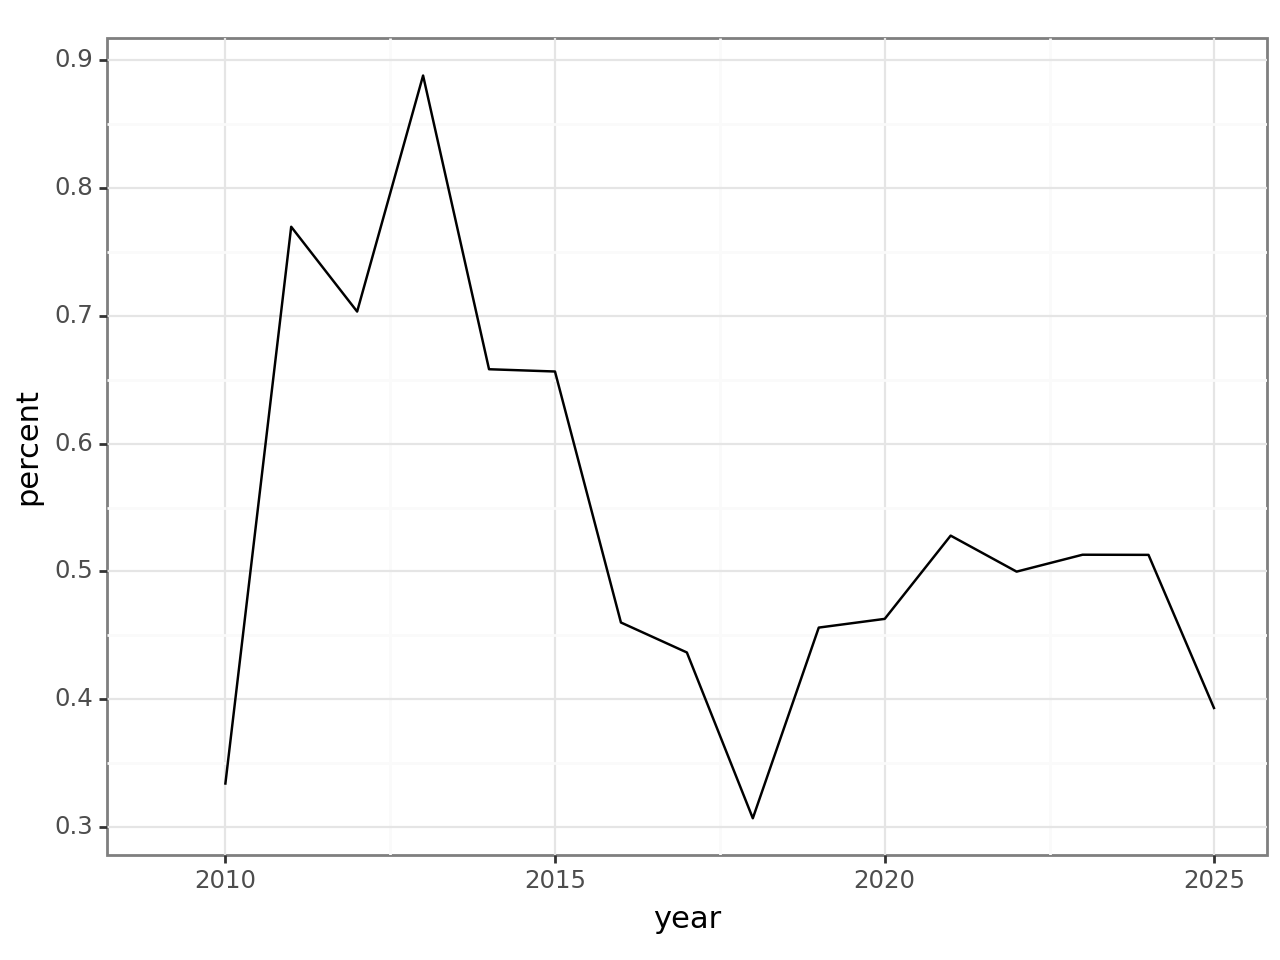

<Figure Size: (640 x 480)>

In [29]:
# human metagenomes over time
soil_by_year = with_human.group_by(('year', (pl.col('organism').str.contains('gut') | pl.col('organism').str.contains('feces') | pl.col('organism').str.contains('human')).alias('soil'))).len()
soil_by_year2 = soil_by_year.pivot('soil', values='len')
soil_by_year2 = soil_by_year2.with_columns((pl.col('true') / (pl.col('false')+pl.col('true'))).alias('percent'))
ggplot(soil_by_year2) + geom_line(aes(x='year', y='percent'))

In [31]:
with_human.filter(pl.col('year')==2013).group_by('is_human').len()

is_human,len
bool,u32
false,338
true,2670
